# NOTEBOOK 2: MINERÍA DE DATOS — MODELOS PREDICTIVOS
**Dataset:** Delitos Informáticos en Colombia (limpio)  
**Variable objetivo:** `CRIMINALIDAD` (SI=1 / NO=0)  
**Modelos:** Árbol de Decisión, KNN, Red Neuronal (MLP), SVM, Random Forest

## 0. Instalación e importación de librerías

In [1]:
import sys
import subprocess

print("Limpiando e instalando versiones compatibles...")

# Limpiar caché
subprocess.run([sys.executable, "-m", "pip", "cache", "purge"], capture_output=True)

# Actualizar pip y herramientas base
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"], 
               capture_output=True)

# === SOLUCIÓN PRINCIPAL ===
# Forzar versiones compatibles
commands = [
    [sys.executable, "-m", "pip", "install", "--upgrade", "numpy==1.26.4"],  
    [sys.executable, "-m", "pip", "install", "--upgrade", "--no-deps", "scikit-learn"],
    [sys.executable, "-m", "pip", "install", "--upgrade", "scipy"],        
]

for cmd in commands:
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print("Completado", " ".join(cmd[-2:]), "→ OK")
    else:
        print("Error en:", " ".join(cmd[-2:]))
        print(result.stderr[:300])

print("\nInstalación terminada.")

Limpiando e instalando versiones compatibles...
Completado --upgrade numpy==1.26.4 → OK
Completado --no-deps scikit-learn → OK
Completado --upgrade scipy → OK

Instalación terminada.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
import joblib

pd.set_option('display.max_columns', None)
print('Librerías importadas correctamente')

Librerías importadas correctamente


---
## 1. OBJETIVO DEL MODELO

**Objetivo:** Construir un modelo de clasificación que prediga si un caso de delito informático en Colombia tiene carácter de **criminalidad organizada** (`CRIMINALIDAD = SI`) o no (`CRIMINALIDAD = NO`), basándose en características del proceso judicial como el estado del caso, la etapa procesal, la ley aplicable, la ubicación geográfica y el tipo de delito.

**Tipo de problema:** Clasificación binaria (SI / NO)  
**Utilidad:** Permite a las autoridades priorizar recursos de investigación en casos con mayor probabilidad de estar ligados a redes criminales organizadas.

---
## 2. CARGA Y PREPARACIÓN DE DATOS

In [7]:
# Cargar el dataset limpio generado en el Notebook 1
df = pd.read_csv('outputs/datasets/Delitos_Informaticos_Limpio.csv', low_memory=False)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Variable objetivo — CRIMINALIDAD:')
print(df['CRIMINALIDAD'].value_counts())
print()
df.head(3)

Dataset cargado: 63,705 filas × 16 columnas
Variable objetivo — CRIMINALIDAD:
CRIMINALIDAD
SI    49970
NO    13735
Name: count, dtype: int64



,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSION,ESTADO,ETAPA_CASO,LEY,PAIS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,ANO_HECHOS,ANO_ENTRADA,ANO_DENUNCIA,DELITO,TOTAL_PROCESOS,PERIODO_HECHO
0,NO,SI,NO,INACTIVO,INDAGACIÓN,LEY 906,COLOMBIA,SANTANDER,FLORIDABLANCA,DIRECCIÓN SECCIONAL DE SANTANDER,2020,2020,2020.0,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,50,2020_2022
1,NO,SI,NO,INACTIVO,INDAGACIÓN,LEY 906,COLOMBIA,"BOGOTÁ, D. C.","BOGOTÁ, D.C.",DIRECCIÓN SECCIONAL DE BOGOTÁ,2023,2023,2023.0,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,116,2023_ADELANTE
2,SI,NO,NO,ACTIVO,INDAGACIÓN,LEY 906,COLOMBIA,CAQUETÁ,FLORENCIA,DIRECCIÓN SECCIONAL DE CAQUETÁ,2025,2025,2025.0,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,104,2023_ADELANTE


### 2.1 Selección de features

In [8]:
# Seleccionar las columnas features y la variable objetivo
FEATURES = [
    'ES_ARCHIVO',          # Si fue archivado (SI/NO)
    'ES_PRECLUSION',       # Si hubo preclusión (SI/NO)
    'ESTADO',              # Estado del proceso (ACTIVO/INACTIVO)
    'ETAPA_CASO',          # Etapa procesal
    'LEY',                 # Ley aplicada
    'PAIS_HECHO',          # País donde ocurrió
    'DEPARTAMENTO_HECHO',  # Departamento
    'ANO_HECHOS',          # Año del hecho
    'ANO_ENTRADA',         # Año de entrada al sistema
    'GRUPO_DELITO_ENCODED' if 'GRUPO_DELITO_ENCODED' in df.columns else 'TOTAL_PROCESOS',
    'TOTAL_PROCESOS',      # Total de procesos asociados
    'PERIODO_HECHO',       # Período temporal (feature engineering)
]

TARGET = 'CRIMINALIDAD'

# Filtrar solo columnas que existen en el dataset
FEATURES = [f for f in FEATURES if f in df.columns]
# Eliminar duplicados
FEATURES = list(dict.fromkeys(FEATURES))

print(f'Features seleccionadas ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  - {f}: {df[f].dtype} | {df[f].nunique()} valores únicos')

Features seleccionadas (11):
  - ES_ARCHIVO: object | 2 valores únicos
  - ES_PRECLUSION: object | 2 valores únicos
  - ESTADO: object | 2 valores únicos
  - ETAPA_CASO: object | 5 valores únicos
  - LEY: object | 3 valores únicos
  - PAIS_HECHO: object | 2 valores únicos
  - DEPARTAMENTO_HECHO: object | 34 valores únicos
  - ANO_HECHOS: int64 | 17 valores únicos
  - ANO_ENTRADA: int64 | 17 valores únicos
  - TOTAL_PROCESOS: int64 | 116 valores únicos
  - PERIODO_HECHO: object | 4 valores únicos


### 2.2 Codificación de variables categóricas

In [9]:
df_model = df[FEATURES + [TARGET]].copy()

# Codificar variable objetivo
le_target = LabelEncoder()
df_model[TARGET] = le_target.fit_transform(df_model[TARGET])  # NO=0, SI=1
print(f'Codificación objetivo: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# Codificar todas las features categóricas con LabelEncoder
encoders = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'  Codificada: {col} → {df_model[col].nunique()} valores')

# Verificar que no haya nulos
df_model.dropna(inplace=True)
print(f'\nDataset listo para modelos: {df_model.shape}')

Codificación objetivo: {'NO': 0, 'SI': 1}
  Codificada: ES_ARCHIVO → 2 valores
  Codificada: ES_PRECLUSION → 2 valores
  Codificada: ESTADO → 2 valores
  Codificada: ETAPA_CASO → 5 valores
  Codificada: LEY → 3 valores
  Codificada: PAIS_HECHO → 2 valores
  Codificada: DEPARTAMENTO_HECHO → 34 valores
  Codificada: PERIODO_HECHO → 4 valores

Dataset listo para modelos: (63705, 12)


### 2.3 División en entrenamiento y prueba

In [10]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado de features (necesario para KNN, SVM y Red Neuronal)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Datos de entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Datos de prueba:        {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Distribución de CRIMINALIDAD en entrenamiento:')
print(y_train.value_counts().rename({0:'NO', 1:'SI'}))
print('\nDistribución de CRIMINALIDAD en prueba:')
print(y_test.value_counts().rename({0:'NO', 1:'SI'}))

Datos de entrenamiento: 50,964 registros (80.0%)
Datos de prueba:        12,741 registros (20.0%)

Distribución de CRIMINALIDAD en entrenamiento:
CRIMINALIDAD
SI    39976
NO    10988
Name: count, dtype: int64

Distribución de CRIMINALIDAD en prueba:
CRIMINALIDAD
SI    9994
NO    2747
Name: count, dtype: int64


---
## 3. CONFIGURACIÓN Y ENTRENAMIENTO DE MODELOS

> Se usa `class_weight='balanced'` donde aplica para compensar el desbalance (78% SI / 22% NO).

### 3.1 Modelo 1 — Árbol de Decisión

=== ÁRBOL DE DECISIÓN ===
Configuración: max_depth=5, criterion=gini, class_weight=balanced

Accuracy en test: 0.6070 (60.70%)

Reporte de clasificación:
              precision    recall  f1-score   support

          NO       0.35      0.93      0.50      2747
          SI       0.96      0.52      0.67      9994

    accuracy                           0.61     12741
   macro avg       0.65      0.72      0.59     12741
weighted avg       0.83      0.61      0.64     12741



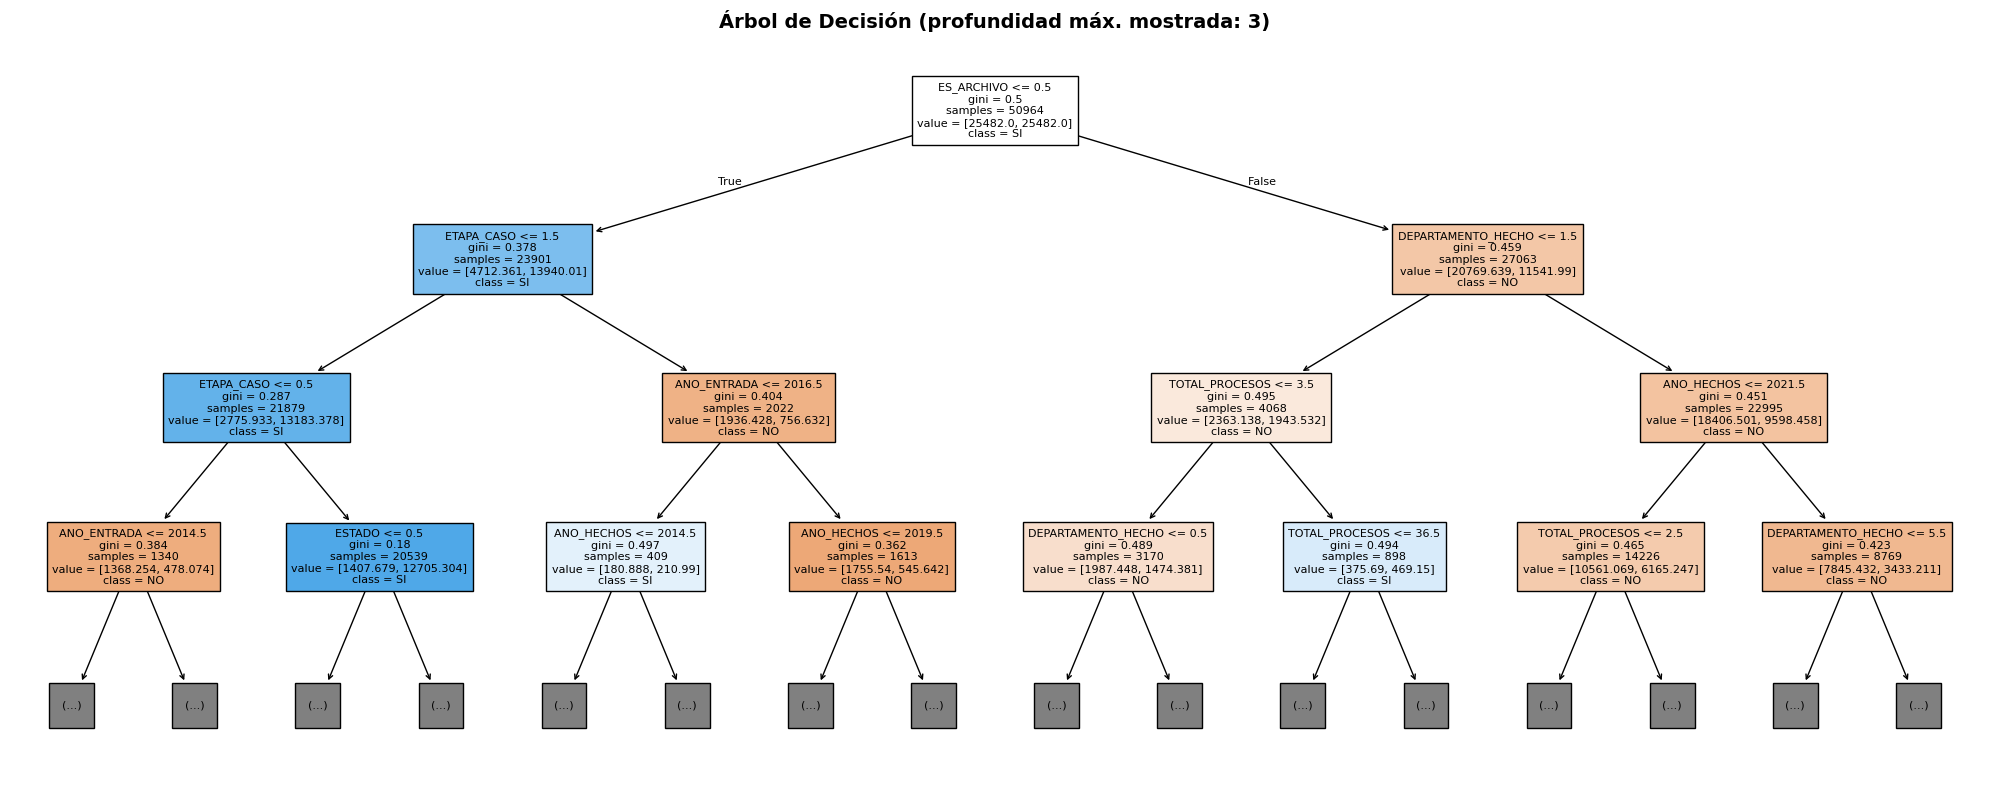

Árbol guardado como arbol_decision.png


In [11]:
print('=== ÁRBOL DE DECISIÓN ===')
print('Configuración: max_depth=5, criterion=gini, class_weight=balanced')
print()

arbol = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, y_pred_arbol)
print(f'Accuracy en test: {acc_arbol:.4f} ({acc_arbol*100:.2f}%)')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_arbol, target_names=['NO','SI']))

# Visualizar árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(arbol, feature_names=FEATURES, class_names=['NO','SI'],
          filled=True, fontsize=8, ax=ax, max_depth=3)
ax.set_title('Árbol de Decisión (profundidad máx. mostrada: 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_decision.png', dpi=80, bbox_inches='tight')
plt.show()
print('Árbol guardado como arbol_decision.png')

### 3.2 Modelo 2 — KNN (K-Nearest Neighbors)

In [12]:
print('=== KNN (K-Nearest Neighbors) ===')
print('Configuración: k=7, weights=distance, metric=euclidean (datos escalados)')
print()

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
knn.fit(X_train_sc, y_train)    # KNN requiere datos escalados
y_pred_knn = knn.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy en test: {acc_knn:.4f} ({acc_knn*100:.2f}%)')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_knn, target_names=['NO','SI']))

=== KNN (K-Nearest Neighbors) ===
Configuración: k=7, weights=distance, metric=euclidean (datos escalados)

Accuracy en test: 0.7729 (77.29%)

Reporte de clasificación:
              precision    recall  f1-score   support

          NO       0.46      0.35      0.40      2747
          SI       0.83      0.89      0.86      9994

    accuracy                           0.77     12741
   macro avg       0.65      0.62      0.63     12741
weighted avg       0.75      0.77      0.76     12741



### 3.3 Modelo 3 — Red Neuronal (MLP)

In [13]:
print('=== RED NEURONAL (MLP — Multi-Layer Perceptron) ===')
print('Configuración: capas=(100,50), relu, adam, max_iter=300 (datos escalados)')
print()

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train_sc, y_train)    # MLP requiere datos escalados
y_pred_mlp = mlp.predict(X_test_sc)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'Accuracy en test: {acc_mlp:.4f} ({acc_mlp*100:.2f}%)')
print(f'Iteraciones realizadas: {mlp.n_iter_}')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_mlp, target_names=['NO','SI']))

=== RED NEURONAL (MLP — Multi-Layer Perceptron) ===
Configuración: capas=(100,50), relu, adam, max_iter=300 (datos escalados)

Accuracy en test: 0.8064 (80.64%)
Iteraciones realizadas: 47

Reporte de clasificación:
              precision    recall  f1-score   support

          NO       0.78      0.14      0.24      2747
          SI       0.81      0.99      0.89      9994

    accuracy                           0.81     12741
   macro avg       0.79      0.57      0.56     12741
weighted avg       0.80      0.81      0.75     12741



### 3.4 Modelo 4 — SVM (Support Vector Machine)

In [14]:
print('=== SVM (Support Vector Machine) ===')
print('Configuración: kernel=rbf, C=1.0, class_weight=balanced (datos escalados)')
print()

# Usamos una muestra del dataset para SVM 
n_sample = min(15000, len(X_train_sc))
idx = np.random.RandomState(42).choice(len(X_train_sc), n_sample, replace=False)
X_train_svm = X_train_sc[idx]
y_train_svm = y_train.iloc[idx]

print(f'SVM entrenado con muestra de {n_sample:,} registros (por eficiencia computacional)')

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_train_svm, y_train_svm)
y_pred_svm = svm.predict(X_test_sc)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy en test: {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_svm, target_names=['NO','SI']))

=== SVM (Support Vector Machine) ===
Configuración: kernel=rbf, C=1.0, class_weight=balanced (datos escalados)

SVM entrenado con muestra de 15,000 registros (por eficiencia computacional)
Accuracy en test: 0.6021 (60.21%)

Reporte de clasificación:
              precision    recall  f1-score   support

          NO       0.35      0.95      0.51      2747
          SI       0.98      0.51      0.67      9994

    accuracy                           0.60     12741
   macro avg       0.66      0.73      0.59     12741
weighted avg       0.84      0.60      0.63     12741



### 3.5 Modelo 5 — Random Forest

In [15]:
print('=== RANDOM FOREST ===')
print('Configuración: 200 árboles, max_depth=10, class_weight=balanced')
print()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy en test: {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_rf, target_names=['NO','SI']))

# Feature importance
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print()
print('Importancia de variables (Random Forest):')
print(importancias.round(4))

=== RANDOM FOREST ===
Configuración: 200 árboles, max_depth=10, class_weight=balanced

Accuracy en test: 0.6310 (63.10%)

Reporte de clasificación:
              precision    recall  f1-score   support

          NO       0.36      0.93      0.52      2747
          SI       0.97      0.55      0.70      9994

    accuracy                           0.63     12741
   macro avg       0.67      0.74      0.61     12741
weighted avg       0.84      0.63      0.66     12741


Importancia de variables (Random Forest):
ES_ARCHIVO            0.2850
ESTADO                0.2648
ETAPA_CASO            0.1808
ANO_ENTRADA           0.0785
DEPARTAMENTO_HECHO    0.0744
ANO_HECHOS            0.0582
TOTAL_PROCESOS        0.0311
PERIODO_HECHO         0.0156
ES_PRECLUSION         0.0081
LEY                   0.0034
PAIS_HECHO            0.0000
dtype: float64


---
## 4. EVALUACIÓN COMPARATIVA DE MODELOS

In [ ]:
# Tabla comparativa de resultados
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = []
modelos_info = [
    ('Árbol de Decisión', y_pred_arbol),
    ('KNN',               y_pred_knn),
    ('Red Neuronal (MLP)',y_pred_mlp),
    ('SVM',               y_pred_svm),
    ('Random Forest',     y_pred_rf),
]

for nombre, y_pred in modelos_info:
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1-Score', ascending=False)
df_resultados = df_resultados.set_index('Modelo')
df_resultados = df_resultados.round(4)

print('=== COMPARACIÓN DE MODELOS ===')
print(df_resultados.to_string())
print()
mejor = df_resultados['F1-Score'].idxmax()
print(f'Mejor modelo según F1-Score: {mejor}')

In [ ]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de métricas
df_resultados[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', ax=axes[0], edgecolor='white', rot=20
)
axes[0].set_title('Métricas por Modelo', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Puntuación')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Umbral 0.80')

# Gráfico de F1
df_resultados['F1-Score'].sort_values().plot(
    kind='barh', ax=axes[1],
    color=['#f44336' if v < 0.7 else '#FF9800' if v < 0.8 else '#4CAF50'
           for v in df_resultados['F1-Score'].sort_values()],
    edgecolor='white'
)
axes[1].set_title('Ranking por F1-Score', fontweight='bold', fontsize=13)
axes[1].set_xlabel('F1-Score')
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(df_resultados['F1-Score'].sort_values()):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=100, bbox_inches='tight')
plt.show()
print('Gráfico guardado como comparacion_modelos.png')

In [ ]:
# Matrices de confusión de todos los modelos
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (nombre, y_pred) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['NO','SI'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{nombre}\nAcc={acc:.3f}', fontsize=9, fontweight='bold')

plt.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=100, bbox_inches='tight')
plt.show()
print('Matrices guardadas como matrices_confusion.png')

---
## 5. HIPERPARAMETRIZACIÓN CON GRIDSEARCH

Se aplica GridSearchCV al mejor modelo identificado en la comparación.

In [ ]:
print(f'Aplicando GridSearchCV al mejor modelo: {mejor}')
print()

# ===== GRIDSEARCH PARA RANDOM FOREST =====
# (Si el mejor modelo es otro, ajustar el grid abajo)

param_grid_rf = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features':  ['sqrt', 'log2']
}

print('Parámetros a evaluar:')
for p, vals in param_grid_rf.items():
    print(f'  {p}: {vals}')

total_combos = 1
for v in param_grid_rf.values():
    total_combos *= len(v)
print(f'\nTotal combinaciones: {total_combos}')
print(f'Con CV=3: {total_combos * 3} entrenamientos')
print()
print('Este proceso puede tardar varios minutos...')

In [ ]:
# Ejecutar GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print()
print('GridSearch completado')
print(f'Mejores parámetros encontrados:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor F1-Score en CV: {grid_search.best_score_:.4f}')

In [ ]:
# Evaluar el modelo hiperparametrizado en el conjunto de prueba
mejor_modelo = grid_search.best_estimator_
y_pred_best = mejor_modelo.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average='weighted')

print('=== MODELO HIPERPARAMETRIZADO vs MODELO BASE ===')
print(f'{'Métrica':<20} {'Modelo Base':>15} {'Tras GridSearch':>15}')
print('-'*50)
print(f'{'Accuracy':<20} {acc_rf:>15.4f} {acc_best:>15.4f}')
print(f'{'F1-Score':<20} {df_resultados.loc["Random Forest","F1-Score"]:>15.4f} {f1_best:>15.4f}')
print()
print('Reporte completo del modelo optimizado:')
print(classification_report(y_test, y_pred_best, target_names=['NO','SI']))

In [ ]:
# Visualizar importancia de variables del modelo final
imp_best = pd.Series(mejor_modelo.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50' if v > 0.15 else '#2196F3' if v > 0.05 else '#90CAF9' for v in imp_best]
imp_best.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Importancia de Variables — Modelo Final (Random Forest Optimizado)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia')
for i, v in enumerate(imp_best):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Gráfico guardado como feature_importance.png')

---
## 6. GUARDAR EL MODELO ENTRENADO

In [ ]:
# Guardar el modelo, scaler y encoders para usarlos en el Notebook 3 (despliegue)
joblib.dump(mejor_modelo, 'modelo_final.pkl')
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(encoders,     'encoders.pkl')
joblib.dump(le_target,    'le_target.pkl')
joblib.dump(FEATURES,     'features.pkl')

print('Archivos guardados para el despliegue:')
print('   - modelo_final.pkl')
print('   - scaler.pkl')
print('   - encoders.pkl')
print('   - le_target.pkl')
print('   - features.pkl')